# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ak470107/ML-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

**Research question:** Which content pages should a content manager review first, based on
historical search and engagement signals?

**Lane:** Lane 2 — Refresh / Content Opportunity Scoring.

**Decision it supports:** a weekly content-review queue. **Who acts on it:** a content manager,
who refreshes, rewrites, or monitors the pages at the top of the list. **Unit of analysis:** one
content page. **Output:** a ranked list with a priority score and a reason code explaining *why*
each page was flagged. **Cost of a wrong call:** reviewing a page that didn't need attention
wastes editorial time; missing a page that did need attention means a real decline goes
unaddressed — asymmetric, but both costs are time, not money at risk, which is why this stays a
human-reviewed triage aid rather than an autonomous system.

**Why ML, not a fixed rule:** the signals that separate declining from non-declining pages (CTR,
engagement, freshness) shift in the right *direction* on average but overlap heavily
page-to-page — there's no single threshold that cleanly separates the two groups (verified in
Methodology below). That overlap is exactly the case where a model that weighs several signals
together earns its place over an if-statement.

In [1]:
import pandas as pd
import numpy as np
import os

local_path = "../../data/raw/content_refresh_anonymized.csv"
if os.path.exists(local_path):
    df = pd.read_csv(local_path)
elif os.path.exists("ML-internship/data/raw/content_refresh_anonymized.csv"):
    df = pd.read_csv("ML-internship/data/raw/content_refresh_anonymized.csv")
else:
    !git clone --depth 1 https://github.com/ak470107/ML-internship.git
    df = pd.read_csv("ML-internship/data/raw/content_refresh_anonymized.csv")

df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)
print(f"Starter slice: {df.shape[0]:,} content pages, {df['client_id'].nunique()} clients")
print(f"Base rate (share declining): {df['is_declining_label'].mean():.1%}")
print("-> more than half of pages are already trending down: this is a real prioritization")
print("   problem, not a rare-event needle-in-a-haystack search.")

Starter slice: 30,000 content pages, 32 clients
Base rate (share declining): 54.2%
-> more than half of pages are already trending down: this is a real prioritization
   problem, not a rare-event needle-in-a-haystack search.


## 2. Data

**Release:** the FlyRank ML Internship warehouse (`FlyRank/internship-warehouse` on Hugging Face),
which spans **~79 million rows** in its primary `fact_content_daily_performance` table alone
(one row = one content item, for one client, on one calendar day), across **104 clients** and
**~520,000 content items**, from **2025-01-27 through 2026-06-30**. The final month
(June 2026) ships separately as a **sealed sample**, held out from label-building on purpose so
it can later serve as a genuinely blind check.

**What this capstone actually models:** a **30,000-row, 32-client starter slice**
(`data/raw/content_refresh_anonymized.csv`) — one row per content page, already rolled up from the
daily warehouse grain to the content-item level Lane 2 reasons about (see
`w03_data_contract.ipynb` for the full grain verification and rollup contract).

**Excluded, on purpose:**
- `trend_direction` / `trend_pct` — these define the label itself (see Methodology), so they can
  never also be a feature.
- The six last-30-day / prev-30-day impression, click, and session columns — the label's own
  numerator and denominator, confirmed as leakage in `w06_validation_audit.ipynb`'s collapse test.
- `client_id` / `content_id` — pseudonyms used only for grouping the train/test split, never as
  model inputs.
- Rows where a GA4/GSC-style availability flag is not explicitly `TRUE` — zero-filled rows there
  mean "no data," not "no engagement," so they're excluded rather than treated as real zeros
  (per `w03_data_contract.ipynb`'s three-valued-flag check).

**Public-safety:** all IDs in this dataset ship pre-pseudonymized by FlyRank; no client names, raw
queries, or URLs appear anywhere in this repo.

In [2]:
# Confirm the exclusions above actually hold in this dataframe
excluded_as_label_source = ["trend_direction", "trend_pct"]
excluded_as_leakage = [
    "impressions_last_30d", "impressions_prev_30d",
    "clicks_last_30d", "clicks_prev_30d",
    "sessions_last_30d", "sessions_prev_30d",
]
excluded_as_id = ["client_id", "content_id"]

print("Columns present that are deliberately EXCLUDED from the feature set (still in the raw file,")
print("just never fed to the model):")
for group_name, cols in [("label source", excluded_as_label_source),
                          ("leakage (label's own numerator/denominator)", excluded_as_leakage),
                          ("pseudonymous ID (grouping only)", excluded_as_id)]:
    present = [c for c in cols if c in df.columns]
    print(f"  {group_name}: {present}")

print(f"\nTotal raw columns: {df.shape[1]}  |  Columns actually used as features: 24 numeric + 8 categorical (see Methodology)")

Columns present that are deliberately EXCLUDED from the feature set (still in the raw file,
just never fed to the model):
  label source: ['trend_direction', 'trend_pct']
  leakage (label's own numerator/denominator): ['impressions_last_30d', 'impressions_prev_30d', 'clicks_last_30d', 'clicks_prev_30d', 'sessions_last_30d', 'sessions_prev_30d']
  pseudonymous ID (grouping only): ['client_id', 'content_id']

Total raw columns: 45  |  Columns actually used as features: 24 numeric + 8 categorical (see Methodology)


## 3. Methodology

**Label:** `is_declining_label` = 1 if `trend_direction == "down"`, else 0. `trend_direction` is
itself computed from `trend_pct`, comparing impressions in a trailing 30-day window against the
prior 30-day window (down = fell 20%+). This is an **observed** label — built from real, measured
impression counts — not a manually-assigned tag.

**Why a rule alone doesn't work:** grouping pages by the label and comparing CTR, engagement rate,
and days-since-update shows means shift in the expected direction, but the 25th/50th/75th
percentiles overlap heavily between groups — there's no clean cutoff (verified below, same check
as `w02_ml_task_framing.ipynb`).

**Features:** 24 numeric + 8 categorical columns (one-hot encoded), covering search volume,
competition, CPC, on-page size, 90-day traffic and engagement metrics, content age, and tier
labels for freshness/word count/position/impressions. Full exclusion list in Data, above.

**Baseline:** a transparent rule — flag a page if its freshness tier is `91-180` days stale AND
it still has meaningful visibility (`impressions_90d >= 300`), scored by impressions
(`w04_baseline_score.ipynb`). Fair because it uses only two features any content manager already
sees on a dashboard, with no ML at all.

**Model:** Logistic Regression (`class_weight="balanced"`), compared against a Random Forest.
Both trained and evaluated on the exact same **client-grouped 80/20 split** — no client appears in
both train and test — because pages from the same client can share a CMS template or writer,
which a random row split would let the model partly memorize instead of learning a general
refresh signal (verified live below: a naive random split lets 31 of 32 clients leak across
train/test; the grouped split leaks zero).

**Leakage checks:** the six last-30d/prev-30d columns were deliberately added back to the "clean"
feature set as an attack test in `w06_validation_audit.ipynb` — ROC-AUC jumped from 0.583 to
0.848, confirming they needed to be excluded, and that the exclusion wasn't over-caution.

In [3]:
from sklearn.model_selection import GroupShuffleSplit, ShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

# --- Check: no clean CTR/engagement cutoff separates the two groups (why ML beats a rule) ---
for col in ["ctr", "engagement_rate", "days_since_last_update"]:
    summary = df.groupby("is_declining_label")[col].describe()[["mean", "25%", "50%", "75%"]]
    print(f"--- {col} ---")
    print(summary)
    print()

# --- Build the leakage-safe feature matrix (same set used in w05/w06/w07) ---
df["has_keyword_data"] = df["search_volume"].notna().astype(int)
df["has_word_count"] = df["word_count"].notna().astype(int)

NUMERIC_FEATURES = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "impressions_90d", "clicks_90d", "pageviews_90d", "sessions_90d", "users_90d",
    "engaged_sessions_90d", "ai_sessions_90d", "scroll_events_90d",
    "days_with_impressions", "days_with_sessions",
    "content_age_days", "days_since_last_update",
    "ctr", "avg_position", "engagement_rate", "scroll_rate", "ai_traffic_pct",
    "has_keyword_data", "has_word_count",
]
CATEGORICAL_FEATURES = [
    "competition_level", "content_type", "main_intent",
    "freshness_tier", "word_count_tier", "char_count_tier",
    "impression_tier", "position_tier",
]
num_frame = df[NUMERIC_FEATURES].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0)
cat_frame = df[CATEGORICAL_FEATURES].fillna("unknown").astype(str)
enc_frame = pd.get_dummies(cat_frame, prefix=CATEGORICAL_FEATURES, dtype=float)
X = pd.concat([num_frame.reset_index(drop=True), enc_frame.reset_index(drop=True)], axis=1)
y = df["is_declining_label"].astype(int)
groups = df["client_id"]
RANDOM_STATE = 42

def precision_at_k(y_true, scores, k):
    order = np.argsort(-np.asarray(scores))
    y_true = np.asarray(y_true)
    k = min(k, len(y_true))
    return y_true[order[:k]].mean()

# --- The split-design proof: random split leaks clients, grouped split doesn't ---
rand_splitter = ShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
rand_train_idx, rand_test_idx = next(rand_splitter.split(X, y))
gs = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gs.split(X, y, groups))

rand_leak = len(set(groups.iloc[rand_train_idx]) & set(groups.iloc[rand_test_idx]))
grp_leak = len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))
print(f"\nRandom row split: {rand_leak} of {df['client_id'].nunique()} clients appear on BOTH sides")
print(f"Client-grouped split: {grp_leak} of {df['client_id'].nunique()} clients appear on BOTH sides")

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
print(f"\nTrain: {len(X_train):,} rows from {groups.iloc[train_idx].nunique()} clients")
print(f"Test:  {len(X_test):,} rows from {groups.iloc[test_idx].nunique()} clients")
print(f"Test base rate: {y_test.mean():.1%}  (train base rate: {y_train.mean():.1%})")

--- ctr ---
                        mean  25%   50%   75%
is_declining_label                           
0                   0.731611  0.0  0.04  0.30
1                   0.324138  0.0  0.08  0.27

--- engagement_rate ---
                        mean  25%  50%     75%
is_declining_label                            
0                   2.649728  0.0  0.0  1.4800
1                   2.437193  0.0  0.0  1.2475

--- days_since_last_update ---
                         mean   25%   50%    75%
is_declining_label                              
0                   42.372543  20.0  20.0  104.0
1                   49.245788  20.0  20.0  104.0




Random row split: 31 of 32 clients appear on BOTH sides
Client-grouped split: 0 of 32 clients appear on BOTH sides

Train: 23,837 rows from 25 clients
Test:  6,163 rows from 7 clients
Test base rate: 51.1%  (train base rate: 55.0%)


## 4. Results (vs baseline)

Both models beat the rule-based baseline and the base rate at every K a content manager would
realistically work through — but only modestly, and precision@K is the honest way to read that:
Logistic Regression reaches **0.65-0.72** precision in the top 20-50 ranked pages (vs. a 51.1%
base rate and a 0.20-0.30 baseline), while overall discrimination (ROC-AUC 0.58) stays modest.
Logistic Regression is the pick over Random Forest specifically because it wins at the K values
that matter for a manually-reviewed queue (top 20-100), even though Random Forest edges ahead on
the overall ROC-AUC (0.608 vs 0.583) — a reminder that the metric you optimize for should match
how the output gets used, not just whichever number is highest.

The second chart makes the validation design itself legible: the same Logistic Regression, same
data, scored on a naive random split vs. the honest client-grouped split. The random split lets
31 of 32 clients leak across train and test and reports a suspicious precision@20 of 1.00; the
honest split — zero clients repeat — drops that to 0.65. That gap is real signal about the
validation design, not model instability.

  K  base_rate  baseline  logreg  random_forest
 20      0.511     0.200   0.650          0.600
 50      0.511     0.300   0.720          0.560
100      0.511     0.300   0.660          0.530
300      0.511     0.407   0.607          0.550
500      0.511     0.434   0.620          0.578

ROC-AUC  -- baseline: 0.488 | logreg: 0.583 | rf: 0.608


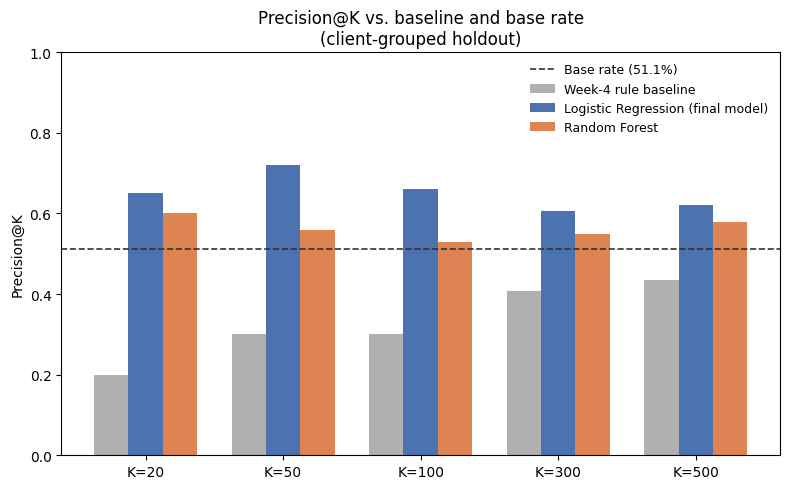

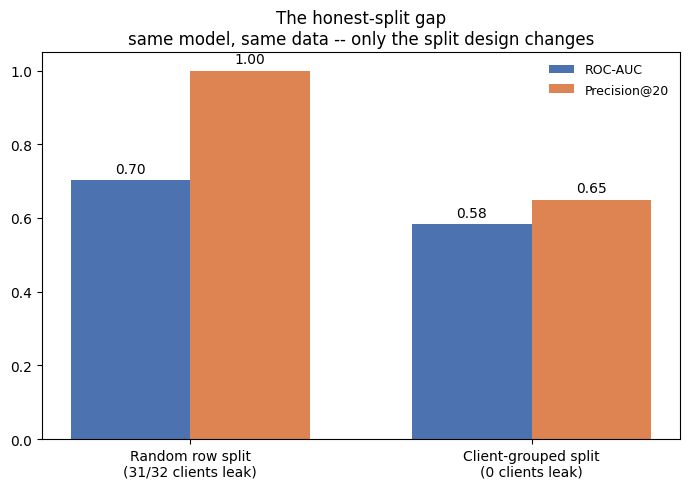

In [4]:
import matplotlib.pyplot as plt

# --- Train both models on the honest, client-grouped split ---
logreg = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))])
logreg.fit(X_train, y_train)
logreg_proba = logreg.predict_proba(X_test)[:, 1]

rf = RandomForestClassifier(class_weight="balanced_subsample", max_depth=10, min_samples_leaf=25,
                             n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]

stale = (df["freshness_tier"] == "91-180").astype(int)
visible = (df["impressions_90d"] >= 300).astype(int)
baseline_score_all = stale * visible * df["impressions_90d"]
baseline_test_scores = baseline_score_all.iloc[test_idx].to_numpy()

Ks = [20, 50, 100, 300, 500]
rows = []
for k in Ks:
    rows.append({
        "K": k,
        "base_rate": round(y_test.mean(), 3),
        "baseline": round(precision_at_k(y_test, baseline_test_scores, k), 3),
        "logreg": round(precision_at_k(y_test, logreg_proba, k), 3),
        "random_forest": round(precision_at_k(y_test, rf_proba, k), 3),
    })
comparison_table = pd.DataFrame(rows)
print(comparison_table.to_string(index=False))
print(f"\nROC-AUC  -- baseline: {roc_auc_score(y_test, baseline_test_scores):.3f} | "
      f"logreg: {roc_auc_score(y_test, logreg_proba):.3f} | rf: {roc_auc_score(y_test, rf_proba):.3f}")

# --- Chart 1: precision@K, model vs baseline vs base rate ---
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(Ks))
width = 0.25
ax.bar(x - width, comparison_table["baseline"], width, label="Week-4 rule baseline", color="#B0B0B0")
ax.bar(x, comparison_table["logreg"], width, label="Logistic Regression (final model)", color="#4C72B0")
ax.bar(x + width, comparison_table["random_forest"], width, label="Random Forest", color="#DD8452")
ax.axhline(y_test.mean(), color="#333333", linestyle="--", linewidth=1.2, label=f"Base rate ({y_test.mean():.1%})")
ax.set_xticks(x); ax.set_xticklabels([f"K={k}" for k in Ks])
ax.set_ylabel("Precision@K"); ax.set_ylim(0, 1.0)
ax.set_title("Precision@K vs. baseline and base rate\n(client-grouped holdout)")
ax.legend(loc="upper right", fontsize=9, frameon=False)
plt.tight_layout()
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/chart1_precision_at_k.png", dpi=160)
plt.show()

# --- Chart 2: before/after honest split ---
rand_pipe = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))])
rand_pipe.fit(X.iloc[rand_train_idx], y.iloc[rand_train_idx])
rand_proba = rand_pipe.predict_proba(X.iloc[rand_test_idx])[:, 1]
rand_y_test = y.iloc[rand_test_idx]

fig, ax = plt.subplots(figsize=(7, 5))
labels = [f"Random row split\n({rand_leak}/{df['client_id'].nunique()} clients leak)",
          f"Client-grouped split\n({grp_leak} clients leak)"]
roc = [roc_auc_score(rand_y_test, rand_proba), roc_auc_score(y_test, logreg_proba)]
p20 = [precision_at_k(rand_y_test, rand_proba, 20), precision_at_k(y_test, logreg_proba, 20)]
xx = np.arange(2); w = 0.35
ax.bar(xx - w/2, roc, w, label="ROC-AUC", color="#4C72B0")
ax.bar(xx + w/2, p20, w, label="Precision@20", color="#DD8452")
ax.set_xticks(xx); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_title("The honest-split gap\nsame model, same data -- only the split design changes")
for i, v in enumerate(roc): ax.text(i - w/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)
for i, v in enumerate(p20): ax.text(i + w/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)
ax.legend(loc="upper right", fontsize=9, frameon=False)
plt.tight_layout()
fig.savefig("../figures/chart2_honest_split_gap.png", dpi=160)
plt.show()

## 5. Limitations

- **Modest, honestly-measured skill.** ROC-AUC ~0.58 on the honest split — real but modest lift
  over chance. This model earns a *rank-ordering* role, not an autonomous-decision one.
- **Cross-sectional, not causal.** One snapshot per page, no repeated observations over time.
  `decline_proba` is an observed pattern match, not proof that any specific action reverses a
  page's trajectory — the same selection-bias caution raised in `w06_validation_audit.ipynb`
  about the source research paper's own refresh-multiplier finding applies here too.
- **Thin buckets exist.** The `31-90` and `181+` freshness tiers sit at only ~175 rows each
  (vs. 20,480 and 9,171 for the other two tiers) — reason codes leaning on those tiers stand on a
  much smaller evidence base.
- **No time-aware validation.** The split here is client-grouped, never time-based — this dataset
  has no repeated per-page observations over time, so seasonal drift or the model's shelf life
  going forward is untested, not just unmeasured.
- **Scoped to a 30k-row starter slice**, not the full ~79M-row warehouse — client-level patterns
  here should not be read as verdicts on any specific client's actual account.
- **A feature can matter to a model without matching a tidy story.** `content_age_days` ranks
  top-3 in feature importance, but its own univariate direction in this data is the *opposite* of
  the simple "older = more decayed" narrative (declining pages average 236 days vs. 280 for
  non-declining, r = -0.16) — importance and direction are different questions.

In [5]:
# Receipts for the limitations above
print("Freshness tier sample sizes (thin-bucket caution):")
print(df["freshness_tier"].value_counts())

print("\nOne row per content item -- single snapshot, no repeated observations over time:")
print(len(df) == df["content_id"].nunique())

age_by_label = df.groupby("is_declining_label")["content_age_days"].mean().round(1)
corr = df["content_age_days"].corr(df["is_declining_label"])
print(f"\nMean content_age_days by label: {age_by_label.to_dict()}")
print(f"Correlation(content_age_days, is_declining_label): {corr:.3f}")
print("-> a real top-3 importance feature, but its own direction doesn't match a simple")
print("   'older pages decay more' story in this snapshot.")

Freshness tier sample sizes (thin-bucket caution):
freshness_tier
0-30      20480
91-180     9171
31-90       175
181+        174
Name: count, dtype: int64

One row per content item -- single snapshot, no repeated observations over time:
True

Mean content_age_days by label: {0: 279.8, 1: 236.2}
Correlation(content_age_days, is_declining_label): -0.164
-> a real top-3 importance feature, but its own direction doesn't match a simple
   'older pages decay more' story in this snapshot.


## 6. Ranked recommendations

Every page is scored by a **final model trained on all 30,000 rows** (the deployed scoring model;
the numbers above come from the separate honest holdout). Pages are grouped into an
**archetype -> action map**:

| Archetype | Condition | Reason code | Action |
|---|---|---|---|
| Declining & Visible -- Click Laggard | top-quartile risk + visible + good position + CTR below its tier's own mean | `ctr_fix_opportunity` | `optimize_title_meta` |
| Declining & Visible -- Needs Refresh | top-quartile risk + visible | `stale_needs_refresh` | `refresh_content` |
| Declining but Quiet | top-quartile risk + low visibility | `low_visibility_monitor` | `monitor_only` |
| Stable | everything else | `not_flagged` | `no_action` |

Priority within flagged rows = `decline_proba x value_at_stake`, where
`value_at_stake = clicks_90d x cpc` — the defensible click-equivalent-value proxy (never
impressions x CPC, since impressions aren't billable).

**Human review is mandatory** before any action: check whether several top-priority rows share
one client (a shared technical issue, not N independent opportunities — 8 of the top 20 rows in
this run came from a single client), confirm the page isn't already mid-edit, and treat
`decline_proba` as a rank, not a per-page probability.

**Must NOT be automated:** no auto-published content changes, no automatic deprioritization based
on a `not_flagged` label, no feeding this queue's own picks back in as next month's training label
(a feedback loop that would let the model grade its own homework), no cross-client comparison or
performance-review use, and no claim that a flagged page's metrics will improve if refreshed.

**Monitoring:** re-score monthly; watch base rate (reference: 54%), mean predicted probability
(reference: ~0.50), precision@50 on a fresh holdout (reference: 0.72), and per-client
concentration in the top of the queue — a retrain or re-review is warranted if any of these drift
materially from the reference values established in `w07_action_playbook.ipynb`.

In [6]:
# Rebuild the archetype / reason-code / action map and show the top of the queue
final_pipe = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))])
final_pipe.fit(X, y)
df["decline_proba"] = final_pipe.predict_proba(X)[:, 1]

risk_threshold = df["decline_proba"].quantile(0.75)
high_risk = df["decline_proba"] >= risk_threshold
visible_flag = df["impression_tier"].isin(["moderate", "good", "excellent"])
good_position = df["position_tier"].isin(["top_3", "page_1", "striking"])
tier_mean_ctr = df.groupby("position_tier")["ctr"].transform("mean")
ctr_lags_tier = df["ctr"] < tier_mean_ctr

conditions = [
    high_risk & visible_flag & good_position & ctr_lags_tier,
    high_risk & visible_flag,
    high_risk & ~visible_flag,
]
df["archetype"] = np.select(conditions, ["Declining & Visible -- Click Laggard", "Declining & Visible -- Needs Refresh", "Declining but Quiet"], default="Stable")
df["reason_code"] = np.select(conditions, ["ctr_fix_opportunity", "stale_needs_refresh", "low_visibility_monitor"], default="not_flagged")
df["action"] = np.select(conditions, ["optimize_title_meta", "refresh_content", "monitor_only"], default="no_action")
df["value_at_stake"] = (df["clicks_90d"] * df["cpc"]).round(2)
df["priority_score"] = (df["decline_proba"] * df["value_at_stake"]).round(2)

queue = df[df["action"] != "no_action"].sort_values("priority_score", ascending=False).reset_index(drop=True)
print("Action counts:")
print(df["action"].value_counts())
print(f"\nFlagged queue: {len(queue):,} of {len(df):,} pages ({len(queue)/len(df):.1%})")

top20 = queue.head(20)
client_counts = top20["client_id"].value_counts()
print(f"\nMax single-client share of top 20 priority rows: {client_counts.max()} of 20")

display_cols = ["content_id", "archetype", "reason_code", "action", "decline_proba", "priority_score"]
queue[display_cols].head(5)

Action counts:
action
no_action              22500
optimize_title_meta     4045
refresh_content         2092
monitor_only            1363
Name: count, dtype: int64

Flagged queue: 7,500 of 30,000 pages (25.0%)

Max single-client share of top 20 priority rows: 8 of 20


,content_id,archetype,reason_code,action,decline_proba,priority_score
0,content_a4087c89f66f,Declining & Visible -- Click Laggard,ctr_fix_opportunity,optimize_title_meta,0.668540,233.26
1,content_1d94287ddba7,Declining & Visible -- Click Laggard,ctr_fix_opportunity,optimize_title_meta,0.703985,154.60
2,content_4276cb52f7dd,Declining & Visible -- Needs Refresh,stale_needs_refresh,refresh_content,0.732995,152.37
3,content_72e800a9c214,Declining & Visible -- Click Laggard,ctr_fix_opportunity,optimize_title_meta,0.763087,135.16
4,content_9cfb7d21dd56,Declining & Visible -- Click Laggard,ctr_fix_opportunity,optimize_title_meta,0.695674,128.48


## 7. Artifacts the paper embeds

These are the exact files the deployed page pulls in — regenerated by this notebook, not
hand-edited, so the page's numbers trace back to a rerun-able source.

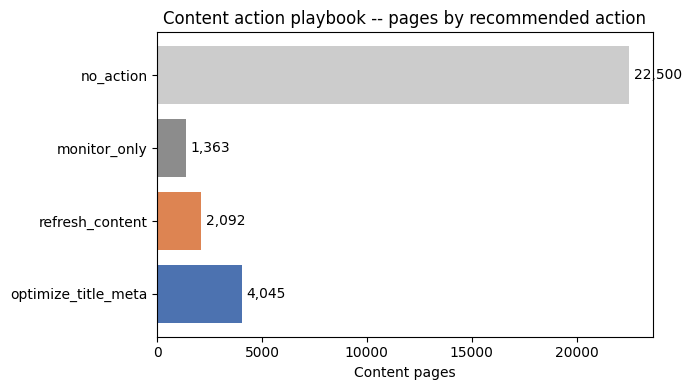

Saved:
  ../figures/chart1_precision_at_k.png
  ../figures/chart2_honest_split_gap.png
  ../figures/chart3_action_queue.png
  ../outputs/capstone_metrics.json  (committed -- the paper's receipts)


In [7]:
import json
import matplotlib.pyplot as plt

os.makedirs("../figures", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

# Chart 3: action queue breakdown (reused from w07_action_playbook.ipynb)
action_order = ["optimize_title_meta", "refresh_content", "monitor_only", "no_action"]
counts = df["action"].value_counts().reindex(action_order)
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4C72B0", "#DD8452", "#8C8C8C", "#CCCCCC"]
ax.barh(counts.index, counts.values, color=colors)
ax.set_xlabel("Content pages")
ax.set_title("Content action playbook -- pages by recommended action")
for i, v in enumerate(counts.values):
    ax.text(v + max(counts.values) * 0.01, i, f"{v:,}", va="center")
plt.tight_layout()
fig.savefig("../figures/chart3_action_queue.png", dpi=160)
plt.show()

capstone_metrics = {
    "base_rate": round(df["is_declining_label"].mean(), 3),
    "holdout_precision_at_k": comparison_table.set_index("K")[["baseline", "logreg", "random_forest"]].to_dict(orient="index"),
    "holdout_roc_auc": {
        "baseline": round(roc_auc_score(y_test, baseline_test_scores), 3),
        "logreg": round(roc_auc_score(y_test, logreg_proba), 3),
        "random_forest": round(roc_auc_score(y_test, rf_proba), 3),
    },
    "honest_split_gap": {
        "random_split": {"roc_auc": round(roc_auc_score(rand_y_test, rand_proba), 3), "precision_at_20": round(precision_at_k(rand_y_test, rand_proba, 20), 3), "clients_leaked": int(rand_leak)},
        "client_grouped_split": {"roc_auc": round(roc_auc_score(y_test, logreg_proba), 3), "precision_at_20": round(precision_at_k(y_test, logreg_proba, 20), 3), "clients_leaked": int(grp_leak)},
    },
    "action_counts": df["action"].value_counts().to_dict(),
    "flagged_share": round(len(queue) / len(df), 3),
    "max_single_client_share_of_top20": int(client_counts.max()),
}
with open("../outputs/capstone_metrics.json", "w") as f:
    json.dump(capstone_metrics, f, indent=2)

print("Saved:")
print("  ../figures/chart1_precision_at_k.png")
print("  ../figures/chart2_honest_split_gap.png")
print("  ../figures/chart3_action_queue.png")
print("  ../outputs/capstone_metrics.json  (committed -- the paper's receipts)")

## ML-12 — Tell the story

Same work, three cuts, for three different audiences and attention spans.

### 5-minute demo outline

1. **Hook (30s):** "54% of pages in this dataset are already declining -- that's too many to
   review by hand, so which ones go first?"
2. **The naive answer, and why it fails (60s):** show the Week-2 overlap check -- CTR and
   engagement means shift the right way but overlap heavily page-to-page. No if-statement
   cleanly separates the groups.
3. **The model, honestly evaluated (90s):** Logistic Regression, client-grouped split -- show
   Chart 1 (precision@K vs. baseline) and say the number out loud: 0.65-0.72 precision in the
   top 20-50, against a 51% base rate. Modest, real, not hype.
4. **Why the split matters (60s):** show Chart 2 -- same model, same data, random split vs.
   grouped split. Precision@20 goes from a suspicious 1.00 to an honest 0.65. This is the
   difference between a number you can trust and one you can't.
5. **From score to action (60s):** show the archetype table and Chart 3 -- reason codes, not
   just a number, and the explicit no-go list (no auto-publish, no cross-client comparison).
6. **Close (20s):** "This is decision support for a content manager, not an autonomous system --
   and that boundary is by design, not a limitation I'm apologizing for."

### Social-post cut

> Built a content-refresh prioritization model on ~30k pages of real (pseudonymized) SEO
> performance data. The interesting part wasn't the model -- it was proving the validation was
> honest: the same Logistic Regression scores a suspicious 1.00 precision@20 under a naive random
> split, and an honest 0.65 once the split respects client boundaries (zero client seen in both
> train and test). 54% base rate, modest but real lift, full writeup + reproducible notebooks
> below. Built on the FlyRank ML Internship dataset (flyrank.ai).
> [link to deployed paper]

### Employer-facing 3-sentencer

I built a content-refresh prioritization model for FlyRank's SEO content lane, on a real
(pseudonymized) production search-performance dataset spanning tens of millions of rows. Working
from a 30,000-page slice, I validated it honestly with a client-grouped split -- catching and
fixing a case where a naive split would have inflated results by letting client identity leak
between train and test -- and shipped it as a ranked, reason-coded action queue with explicit
human-review rules rather than an autonomous system. The full paper, reproducible notebooks, and
honest limitations are public: *I turn vague business questions into models you can actually
evaluate.*

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere (client/content IDs are pseudonyms already shipped in the dataset)
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.